In [ ]:
import numpy as np
import pandas as pd
import rebound
from rebound import Simulation, Particle
import torch

In [ ]:
!pip install sbijax --no-deps
!pip install diffrax optax equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 11.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sbijax 0.3.6 requires arviz==1.0.0, which is not installed.
sbijax 0.3.6 requires blackjax>=1.3, which is not installed.
sbijax 0.3.6 requires dm-haiku>=0.0.16, which is not installed.
sbijax 0.3.6 requires jrnmm==0.1.1.post2, which is not installed.
sbijax 0.3.6 requires surjectors>=0.3.3, which is not installed.
sbijax 0.3.6 requires tfp-nightl

In [ ]:
! pip install sbi rebound

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 611.6 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.9/517.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 20.0 MB/s eta 0:00:00
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53654 sha256=edee20f54560254764c6182dadc4fe31464f896b76cf3e7b2a881c384d86f3d7
  Stored in directory: /root/.cache/pip/wheels/fd/27/c3/8952205ea17b63dc1eaa24031e63111c6a3661cb22cc1e2a3c
Successfully built nflows


In [ ]:
from sbi.inference import NPE, FMPE, NPSE
from sbi import utils as sbi_utils

In [ ]:
from sbi import utils as sbi_utils
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils import BoxUniform

In [ ]:
from sbi.diagnostics import run_sbc, check_sbc
from sbi.analysis.plot import sbc_rank_plot

In [ ]:
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')
sim.add(m=1)
sim.add(m=2e-3, a=1.)
sim.add(m=1e-2, a=2., e=0.1)
sim.add(m=1e-3, a=1.5, e=0.2)
sim.integrate(10000.)

In [ ]:
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits():
    print(o)

9.069481221501414 686.4457888782873 0.0
9.563185496997619 687.4523442227804 0.0
9.344682615920052 688.4220100675009 0.0
-9160.814676004733 -9702.947327981963 0.0
<rebound.Orbit instance, a=0.880060961055079 e=0.33012296683816766 inc=0.0 Omega=0.0 omega=4.682798950859981 f=2.7151728221963722>
<rebound.Orbit instance, a=1.8310020620049035 e=0.11281535219582094 inc=0.0 Omega=0.0 omega=3.9734463613276505 f=3.7425193934890437>
<rebound.Orbit instance, a=-20.681391667269533 e=1.0967047949133608 inc=0.0 Omega=0.0 omega=1.2714346693967347 f=2.7178257573988844>


In [ ]:
def simulate(m1, m2, m3, x1, vx1, x2, vx2, x3, vx3, y1, vy1, y2, vy2, y3, vy3, t_end=200.):
    sim = rebound.Simulation()
    sim.add(m=m1, x=x1, vx=vx1, y=y1, vy=vy1)
    sim.add(m=m2, x=x2, vx=vx2, y=y2, vy=vy2)
    sim.add(m=m3, x=x3, vx=vx3, y=y3, vy=vy3)
    sim.integrator = "ias15"
    sim.integrate(t_end)
    return sim
def summary_statistics(sim):
    particles = sim.particles
    x1, y1, m1 = particles[0].x, particles[0].y, particles[0].m
    x2, y2, m2 = particles[1].x, particles[1].y, particles[1].m
    x3, y3, m3 = particles[2].x, particles[2].y, particles[2].m
    vx1, vy1 = particles[0].vx, particles[0].vy
    vx2, vy2 = particles[1].vx, particles[1].vy
    vx3, vy3 = particles[2].vx, particles[2].vy
    return np.array([m1, m2, m3, x1, vx1, x2, vx2, x3, vx3, y1, vy1, y2, vy2, y3, vy3])

def simulator_single(params: torch.Tensor) -> torch.Tensor:
    if isinstance(params, torch.Tensor):
        params = params.numpy()
    m1, m2, m3, x1, vx1, x2, vx2, x3, vx3, y1, vy1, y2, vy2, y3, vy3 = params
    sim = simulate(m1, m2, m3, x1, vx1, x2, vx2, x3, vx3, y1, vy1, y2, vy2, y3, vy3)
    stats = summary_statistics(sim)
    del sim
    return stats

def simulator_for_sbi(params: torch.Tensor) -> torch.Tensor:
    if params.ndim == 1:
        return torch.tensor(simulator_single(params), dtype=torch.float32)
    else:
        return torch.stack([torch.tensor(simulator_single(p), dtype=torch.float32) for p in params])

# Original Parameters

In [ ]:
prior = sbi_utils.BoxUniform(
    low=torch.tensor([0.1, 0.1, 0.1, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0]),
    high=torch.tensor([10, 10, 10, 5, 10, 5, 10, 5, 10, 5, 10, 5, 10, 5, 10])
)

NameError: name 'sbi_utils' is not defined

In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm

In [ ]:
from multiprocessing import get_context

ctx = get_context("spawn")
all_params = prior.sample((100000,)).numpy()

with ctx.Pool(processes=ctx.cpu_count()) as pool:
    results = list(tqdm(pool.imap(simulator_single, all_params, chunksize=100), total=100000))

theta = torch.tensor(all_params, dtype=torch.float32)
x = torch.from_numpy(np.stack(results).astype(np.float32))

  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
all_params = prior.sample((100000,)).numpy()
results = Parallel(n_jobs=-1, backend="multiprocessing", verbose=10)(
    delayed(simulator_single)(all_params[i]) for i in tqdm(range(100000))
)

theta = torch.tensor(all_params, dtype=torch.float32)
x = torch.from_numpy(np.stack(results).astype(np.float32))

  0%|          | 1/100000 [00:00<9:43:28,  2.86it/s][Parallel(n_jobs=-1)]: Batch computation too fast (0.004067182540893555s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  24 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.022293806076049805s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  59 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  86 tasks      | elapsed:    0.5s
  0%|          | 240/100000 [00:00<03:19, 500.47it/s][Parallel(n_jobs=-1)]: Batch computation too fast (0.19092559814453125s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 118 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    0.9s
  1%|          | 912/100000 [00:03<07:42, 214.47it/s][Parallel(n_jobs=-1)]: Done 598 tasks      | elapsed:   

KeyboardInterrupt: 

In [ ]:
all_theta, all_x = [], []
batch = 1000
for i in range(0, 10000, batch):
    theta, x = simulate_for_sbi(
        simulator_for_sbi,
        proposal=prior,
        num_simulations=batch,
    )
    all_theta.append(theta)
    all_x.append(x)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
theta = torch.cat(all_theta)
x = torch.cat(all_x)

In [ ]:
inference = NPE(prior=prior)
inference.append_simulations(theta, x)
density_estimator = inference.train()

/usr/local/lib/python3.12/dist-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 305 epochs.

In [ ]:
posterior = inference.build_posterior(density_estimator)

In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1, 1, 1, 0, 0, 1, 2, 3, 0.6, 0, 0, 1, 1, 0.9, 0.3)))

In [ ]:
posterior.set_default_x(x_obs)
map_estimate = posterior.map()

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
print("MAP:", map_estimate)

MAP: tensor([[3.1165, 4.5727, 4.7304, 2.4400, 1.2839, 3.4376, 0.5381, 2.6478, 0.7759,
         2.4277, 0.7188, 2.6271, 0.1138, 2.6698, 0.5349]])


In [ ]:
import numpy as np
import glob

theta_files = sorted(glob.glob("theta_batch_*.npy"))
theta_all = np.concatenate([np.load(f) for f in theta_files], axis=0)

x_files = sorted(glob.glob("x_batch_*.npy"))
x_all = np.concatenate([np.load(f) for f in x_files], axis=0)

np.save("theta_combined.npy", theta_all)
np.save("x_combined.npy", x_all)

print(theta_all.shape, x_all.shape)

(99937, 15) (99937, 12)


In [ ]:
theta = np.load('theta_combined.npy')
x = np.load('x_combined.npy')
theta = torch.tensor(theta, dtype=torch.float32)
x = torch.tensor(x, dtype=torch.float32)


In [ ]:
x = torch.cat((theta[:, 0:3], x), dim=1)
theta = theta[:, 3:]

In [ ]:
theta.shape

torch.Size([99937, 12])

In [ ]:
x.shape

torch.Size([99937, 15])

In [ ]:
prior = sbi_utils.BoxUniform(
    low=torch.tensor([0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0]),
    high=torch.tensor([5, 10, 5, 10, 5, 10, 5, 10, 5, 10, 5, 10])
)

In [ ]:
inference = NPE(prior=prior)
inference.append_simulations(theta, x)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)


/usr/local/lib/python3.12/dist-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 288 epochs.

In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1, 1, 1, 0, 0, 1, 2, 3, 0.6, 0, 0, 1, 1, 0.9, 0.3)))
posterior.set_default_x(x_obs)
samples = posterior.sample((1000,), x=x_obs, reject_outside_prior=False)
map_estimate = samples.mean(dim=0)

/tmp/ipykernel_34872/3693340744.py:3: UserWarning: 100.0% of samples drawn with reject_outside_prior=False lie outside the prior support. This may lead to incorrect inference.
  samples = posterior.sample((1000,), x=x_obs, reject_outside_prior=False)


In [ ]:
print("MAP:", map_estimate)

MAP: tensor([ -4.1801,   5.2419,  -0.2238,   3.1011,  -4.8114,   8.4644,   4.6494,
         -1.3721,   4.5329, -22.8714,   0.9933,   2.9391],
       grad_fn=<MeanBackward1>)


In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1, 1, 1, 0, 0, 1, 2, 3, 0.6, 0, 0, 1, 1, 0.9, 0.3)))
posterior.set_default_x(x_obs)
map_estimate = posterior.map()
print("MAP:", map_estimate)

  0%|          | 0/1000 [00:00<?, ?it/s]

                    accepted. It may take a long time to collect the remaining
                    1000 samples. You can prevent very long runtimes by
                    setting `max_sampling_time` to limit runtime, or disabling
                    rejection sampling (e.g. via `reject_outside_prior=False` in
                    `posterior.sample()` when available).Alternatively, consider interrupting (Ctrl-C)
                    and switching to `build_posterior(..., sample_with='mcmc')`.


In [ ]:
import numpy as np

In [ ]:
import torch
from sbi.inference import FMPE
from sbi import utils as sbi_utils

prior = sbi_utils.BoxUniform(
    low=torch.tensor([0.1, 0.1, 0.1, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0]),
    high=torch.tensor([10, 10, 10, 5, 10, 5, 10, 5, 10, 5, 10, 5, 10, 5, 10])
)
theta_tensor = torch.tensor(theta, dtype=torch.float32)
x_tensor = torch.tensor(x, dtype=torch.float32)

inference = FMPE(prior)
inference.append_simulations(theta_tensor, x_tensor).train()
posterior = inference.build_posterior()

/tmp/ipykernel_13706/195347111.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_tensor = torch.tensor(theta, dtype=torch.float32)
/tmp/ipykernel_13706/195347111.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x, dtype=torch.float32)
/usr/local/lib/python3.12/dist-packages/sbi/inference/trainers/vfpe/base_vf_inference.py:167: UserWarning: Data has extreme outliers in dimension(s) [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect trainin

 Neural network successfully converged after 777 epochs.

In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1, 1, 1, 0, 0, 1, 2, 3, 0.6, 0, 0, 1, 1, 0.9, 0.3)))


In [ ]:
posterior.set_default_x(x_obs)
samples = posterior.sample((10000,), x=x_obs)
map_estimate = samples.mean(dim=0)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
posterior.set_default_x(x_obs)
map_estimate = posterior.map()


  0%|          | 0/1000 [00:00<?, ?it/s]

Optimization was interrupted after 185 iterations. 


In [ ]:
print("MAP:", map_estimate)

MAP: tensor([5.4237, 4.4493, 4.4039, 2.1261, 2.1781, 2.6900, 5.9386, 3.1118, 1.3390,
        1.5891, 2.6947, 1.2229, 7.3516, 1.4517, 5.2179])


# Orbit-Only

In [ ]:
def simulate(m1, m2, m3, a1, a2, a3, e1, e2, e3, t_end=100000.):
    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    sim.add(m=1)
    sim.add(m=m1, a=a1, e=e1)
    sim.add(m=m2, a=a2, e=e2)
    sim.add(m=m3, a=a3, e=e3)
    sim.integrator = "whfast"
    min_period = min(a1, a2, a3) ** 1.5
    sim.dt = 0.05 * min_period
    sim.integrate(t_end)
    return sim
def summary_statistics(sim):
    particles = sim.particles
    a1, e1, m1= particles[1].a, particles[1].e, particles[1].m
    a2, e2, m2= particles[2].a, particles[2].e, particles[2].m
    a3, e3, m3= particles[3].a, particles[3].e, particles[3].m
    return np.array([m1, m2, m3, a1, a2, a3, e1, e2, e3])

def simulator_single(params: torch.Tensor) -> torch.Tensor:
    if isinstance(params, torch.Tensor):
        params = params.numpy()
    m1, m2, m3, a1, a2, a3, e1, e2, e3 = params
    sim = simulate(m1, m2, m3, a1, a2, a3, e1, e2, e3)
    stats = summary_statistics(sim)
    del sim
    return stats

def simulator_for_sbi(params: torch.Tensor) -> torch.Tensor:
    if params.ndim == 1:
        return torch.tensor(simulator_single(params), dtype=torch.float32)
    else:
        return torch.stack([torch.tensor(simulator_single(p), dtype=torch.float32) for p in params])

In [ ]:
class MixedPrior(torch.distributions.Distribution):
    arg_constraints = {}
    has_rsample = True
    def __init__(self):
        super().__init__(batch_shape=torch.Size([]), event_shape=torch.Size([9]))
        self.log_mass_dist = torch.distributions.Uniform(
            low=torch.log(torch.tensor([1e-6, 1e-6, 1e-6])),
            high=torch.log(torch.tensor([2e-3, 2e-3, 2e-3]))
        )
        self.log_a_dist = torch.distributions.Uniform(
            low=torch.log(torch.tensor([0.5, 0.5, 0.5])),
            high=torch.log(torch.tensor([10.0, 10.0, 10.0]))
        )
        self.ecc_dist = torch.distributions.Uniform(
            low=torch.tensor([0.0, 0.0, 0.0]),
            high=torch.tensor([0.35, 0.35, 0.35])
        )

    def rsample(self, sample_shape=torch.Size([])):
        masses = torch.exp(self.log_mass_dist.rsample(sample_shape))
        a      = torch.exp(self.log_a_dist.rsample(sample_shape))
        ecc    = self.ecc_dist.rsample(sample_shape)
        return torch.cat([masses, a, ecc], dim=-1)

    def log_prob(self, x):
        masses = x[..., :3]
        a      = x[..., 3:6]
        ecc    = x[..., 6:]
        mass_lp = self.log_mass_dist.log_prob(torch.log(masses)) - torch.log(masses)
        a_lp    = self.log_a_dist.log_prob(torch.log(a)) - torch.log(a)
        ecc_lp  = self.ecc_dist.log_prob(ecc)

        return mass_lp.sum(-1) + a_lp.sum(-1) + ecc_lp.sum(-1)

prior = MixedPrior()

In [ ]:
class MixedPrior2(torch.distributions.Distribution):
    arg_constraints = {}
    has_rsample = True

    def __init__(self):
        super().__init__(batch_shape=torch.Size([]), event_shape=torch.Size([6]))
        self.log_a_dist = torch.distributions.Independent(
            torch.distributions.Uniform(
                low=torch.log(torch.tensor([0.5, 0.5, 0.5])),
                high=torch.log(torch.tensor([10.0, 10.0, 10.0]))
            ), 1)
        self.ecc_dist = torch.distributions.Independent(
            torch.distributions.Uniform(
                low=torch.tensor([0.0, 0.0, 0.0]),
                high=torch.tensor([0.35, 0.35, 0.35])
            ), 1)

    def rsample(self, sample_shape=torch.Size([])):
        a   = torch.exp(self.log_a_dist.rsample(sample_shape))
        ecc = self.ecc_dist.rsample(sample_shape)
        return torch.cat([a, ecc], dim=-1)

    def log_prob(self, x):
        a   = x[..., :3]
        ecc = x[..., 3:]
        a_lp   = self.log_a_dist.log_prob(torch.log(a)) - torch.log(a).sum(-1)
        ecc_lp = self.ecc_dist.log_prob(ecc)
        return a_lp + ecc_lp

    @property
    def support(self):
        return torch.distributions.constraints.independent(
            torch.distributions.constraints.real, 1)
prior = MixedPrior()

In [ ]:
prior2 = MixedPrior2()

In [ ]:
# prior = sbi_utils.BoxUniform(
#     low=torch.tensor([1e-6, 1e-6, 1e-6, 0.2, 0.2, 0.2, 0, 0, 0]),
#     high=torch.tensor([5e-3, 5e-3, 5e-3, 10.0, 10.0, 10.0, 0.7, 0.7, 0.7])
# )

In [ ]:
import os
os.cpu_count()

44

In [ ]:
import time

sample = prior.rsample()
start = time.time()
result = simulator_single(sample)
elapsed = time.time() - start
print(f"Single sim: {elapsed:.2f}s")
print(f"Estimated total for 10000: {elapsed * 10000 / 3600:.1f} hours")

Single sim: 4.97s
Estimated total for 10000: 13.8 hours


In [ ]:
from multiprocessing import Pool
import os
from tqdm import tqdm

def simulate_single_worker(params):
    params = np.array(params)
    m1, m2, m3, a1, a2, a3, e1, e2, e3 = params
    sim = simulate(m1, m2, m3, a1, a2, a3, e1, e2, e3)
    stats = summary_statistics(sim)
    del sim
    return stats

def run_parallel_sims(n_sims, n_cores=None):
    if n_cores is None:
        n_cores = os.cpu_count()

    theta = torch.stack([prior.rsample() for _ in range(n_sims)])
    params_list = [theta[i].numpy() for i in range(n_sims)]

    print(f"Running {n_sims} sims on {n_cores} cores...")
    with Pool(n_cores) as pool:
        results = list(tqdm(
            pool.imap(simulate_single_worker, params_list),
            total=n_sims
        ))

    x = torch.tensor(np.array(results), dtype=torch.float32)
    return theta, x



In [ ]:

theta, x = run_parallel_sims(1000, n_cores = 42)
theta_ = theta[:, 3:]

Running 1000 sims on 42 cores...


  0%|          | 4/1000 [00:04<17:15,  1.04s/it]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
  0%|          | 5/1000 [00:04<15:15,  1.09it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
 12%|█▏        | 122/1000 [00:11<00:48, 18.02it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
 14%|█▍        | 139/1000 [00:12<00:46, 18.65it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeW

In [ ]:
mask = (x[:, -3:] > 1).any(dim=1)


In [ ]:
import matplotlib.pyplot as plt

(array([150.,  84.,  46.,  27.,  24.,  15.,  21.,  16.,  10.,  13.]),
 array([0.50528234, 1.44909549, 2.39290881, 3.3367219 , 4.28053522,
        5.22434855, 6.16816139, 7.11197472, 8.05578804, 8.99960136,
        9.94341469]),
 <BarContainer object of 10 artists>)

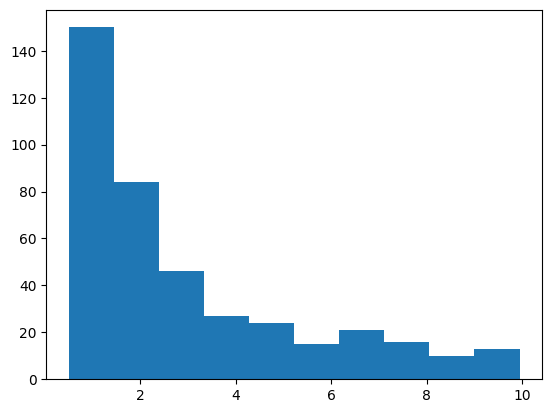

In [ ]:
plt.hist(theta[mask][:, -4])

In [ ]:
torch.sum(mask)

tensor(406)

In [ ]:
for i in range(10, 11):
  theta, x = run_parallel_sims(10000, n_cores = 22)
  theta_ = theta[:, 3:]
  np.save(f'orbit_theta_new_{i}.npy', theta_)
  np.save(f'orbit_x_new_{i}.npy', x)

Running 10000 sims on 22 cores...


  1%|▏         | 130/10000 [00:15<16:36,  9.91it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
  6%|▋         | 631/10000 [01:02<11:50, 13.19it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
  7%|▋         | 655/10000 [01:04<10:47, 14.43it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
  8%|▊         | 828/10000 [01:22<13:07, 11.65it/s]/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], 

In [ ]:
theta_ = theta[:, 3:]

In [ ]:
np.save('orbit_theta.npy', theta_)

In [ ]:
np.save('orbit_x.npy', theta)

In [ ]:
import numpy as np
import glob

theta_files = sorted(glob.glob("orbit_theta_new_*.npy"))
theta_all = np.concatenate([np.load(f) for f in theta_files], axis=0)

x_files = sorted(glob.glob("orbit_x_new_*.npy"))
x_all = np.concatenate([np.load(f) for f in x_files], axis=0)

np.save("theta_combined_new.npy", theta_all)
np.save("x_combined_new.npy", x_all)

print(theta_all.shape, x_all.shape)

(100000, 6) (100000, 9)


In [ ]:
x_all = np.load('x_combined_new.npy')
theta_all = np.load('theta_combined_new.npy')

In [ ]:
theta = torch.Tensor(theta_all)
x = torch.Tensor(x_all)

In [ ]:
x.shape

torch.Size([100000, 9])

In [ ]:
import torch

theta = torch.Tensor(theta_all)
x = torch.Tensor(x_all)

N = x.shape[0]
half = N // 2
mask = (x[:, -3:] > 1).any(dim=1)
cond_idx = torch.where(mask)[0]
non_cond_idx = torch.where(~mask)[0]

cond_idx = cond_idx[torch.randperm(len(cond_idx))]
non_cond_idx = non_cond_idx[torch.randperm(len(non_cond_idx))]

selected_cond = cond_idx
selected_non_cond = non_cond_idx[:half]

selected_idx = torch.cat([selected_cond, selected_non_cond])

selected_idx = selected_idx[torch.randperm(len(selected_idx))]

x_selected = x[selected_idx]
theta_selected = theta[selected_idx]

In [ ]:
x

tensor([[2.8795e-04, 4.0251e-04, 5.0668e-04,  ..., 5.1054e-02, 2.4668e+01,
         4.2541e+01],
        [3.7280e-04, 4.2592e-05, 5.8980e-05,  ..., 9.8749e+00, 5.2730e+02,
         3.0000e+01],
        [9.1427e-06, 8.2366e-04, 2.0265e-04,  ..., 9.1146e+00, 5.1792e-01,
         8.6452e-01],
        ...,
        [3.0271e-06, 6.6031e-04, 3.0168e-04,  ..., 3.1701e-02, 1.9187e+01,
         4.7302e+01],
        [9.2346e-05, 1.9759e-04, 1.4308e-04,  ..., 3.2148e+00, 1.6173e+01,
         1.0039e+00],
        [1.2407e-06, 1.1789e-05, 1.2615e-03,  ..., 4.1251e+01, 2.8389e-01,
         4.3271e-01]])

In [ ]:
torch.max(theta[:, -6:-3])

tensor(10.0000)

In [ ]:
torch.sum(mask)

tensor(41196)

In [ ]:
torch.max(x[:, -3:])

tensor(0.3000)

In [ ]:
theta_selected.shape

torch.Size([55000, 6])

In [ ]:
torch.max(theta[:, :3])

tensor(10.0000)

In [ ]:
x_processed = x.clone()
x_processed[:, :3] = torch.log(x[:, :3].clamp(min=1e-10))
a = x[:, 3:6]
x_processed[:, 3:6] = torch.where(a > 0, torch.log(a.clamp(min=1e-3)), torch.full_like(a, -10.0))
x_processed[:, 6:] = torch.clamp(x[:, 6:], min=0, max=10.0)

In [ ]:
theta_processed = theta.clone()
theta_processed[:, :3] = torch.log(theta[:, :3])

In [ ]:
from sklearn.model_selection import train_test_split

theta_train, theta_test, x_train, x_test = train_test_split(
    theta_processed, x_processed, test_size=0.1, random_state=42
)

In [ ]:
np.save('theta_train_orbit.npy', theta_train)
np.save('theta_test_orbit.npy', theta_test)
np.save('x_train_orbit.npy', x_train)
np.save('x_test_orbit.npy', x_test)

If it's already available, take the train/test from files:

In [ ]:
theta_train = torch.tensor(np.load('theta_train_orbit.npy'))
theta_test = torch.tensor(np.load('theta_test_orbit.npy'))
x_train = torch.tensor(np.load('x_train_orbit.npy'))
x_test = torch.tensor(np.load('x_test_orbit.npy'))

## NPE

In [ ]:
inference = NPE(prior=prior2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()

/usr/local/lib/python3.12/dist-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [6, 7] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 208 epochs.

In [ ]:
posterior = inference.build_posterior(density_estimator)


/usr/local/lib/python3.12/dist-packages/sbi/utils/sbiutils.py:876: UserWarning: The passed discrete prior has no mean or stddev attribute, estimating them from samples to build affine standardizing transform.
  transform = prior_mean_std_transform(prior, device)


In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1e-6, 1e-6, 1e-3, 0.8, 0.9, 1.0, 0, 0, 0.1)))
x_obs[:3] = torch.log(x_obs[:3].clamp(min=1e-10))
a = x_obs[3:6]
x_obs[3:6] = torch.where(a > 0, torch.log(a.clamp(min=1e-3)), torch.full_like(a, -10.0))
x_obs[6:] = torch.clamp(x_obs[6:], min=0, max=10.0)
posterior.set_default_x(x_obs)
# map_estimate = posterior.map()
# print("MAP:", map_estimate)

DirectPosterior sampler for potential_fn=<PosteriorBasedPotential>

In [ ]:
samples = posterior.sample((1000,), x=x_obs, reject_outside_prior=False)
samples[:, :3] = torch.exp(samples[:, :3])
map_estimate = samples.mean(dim=0)

In [ ]:
map_estimate

tensor([2.1476, 3.1428, 1.9229, 0.1881, 0.1676, 0.1934],
       grad_fn=<MeanBackward1>)

In [ ]:
import pickle
with open('NPE.pkl', 'wb') as f:
    pickle.dump(inference, f)

torch.save(density_estimator, 'density_estimator_NPE.pt')

/tmp/ipykernel_19122/4270445801.py:3: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(inference, f)


In [ ]:
import pickle
import torch

with open('NPE.pkl', 'rb') as f:
    inference = pickle.load(f)

density_estimator = torch.load('density_estimator_NPE.pt', weights_only=False)
posterior = inference.build_posterior(density_estimator)

/usr/local/lib/python3.12/dist-packages/sbi/utils/sbiutils.py:876: UserWarning: The passed discrete prior has no mean or stddev attribute, estimating them from samples to build affine standardizing transform.
  transform = prior_mean_std_transform(prior, device)


/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 100 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 1000 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 1000 SBC samples:   0%|          | 0/1000 [00:00<?, ?it/s]

{'ks_pvals': tensor([5.6909e-24, 5.6052e-45, 2.1321e-23, 8.6379e-03, 6.9634e-07, 6.7425e-02]),
 'c2st_ranks': tensor([0.6170, 0.6310, 0.6185, 0.5910, 0.5800, 0.6285], dtype=torch.float64),
 'c2st_dap': tensor([0.5160, 0.5045, 0.5120, 0.5485, 0.5390, 0.5335], dtype=torch.float64)}

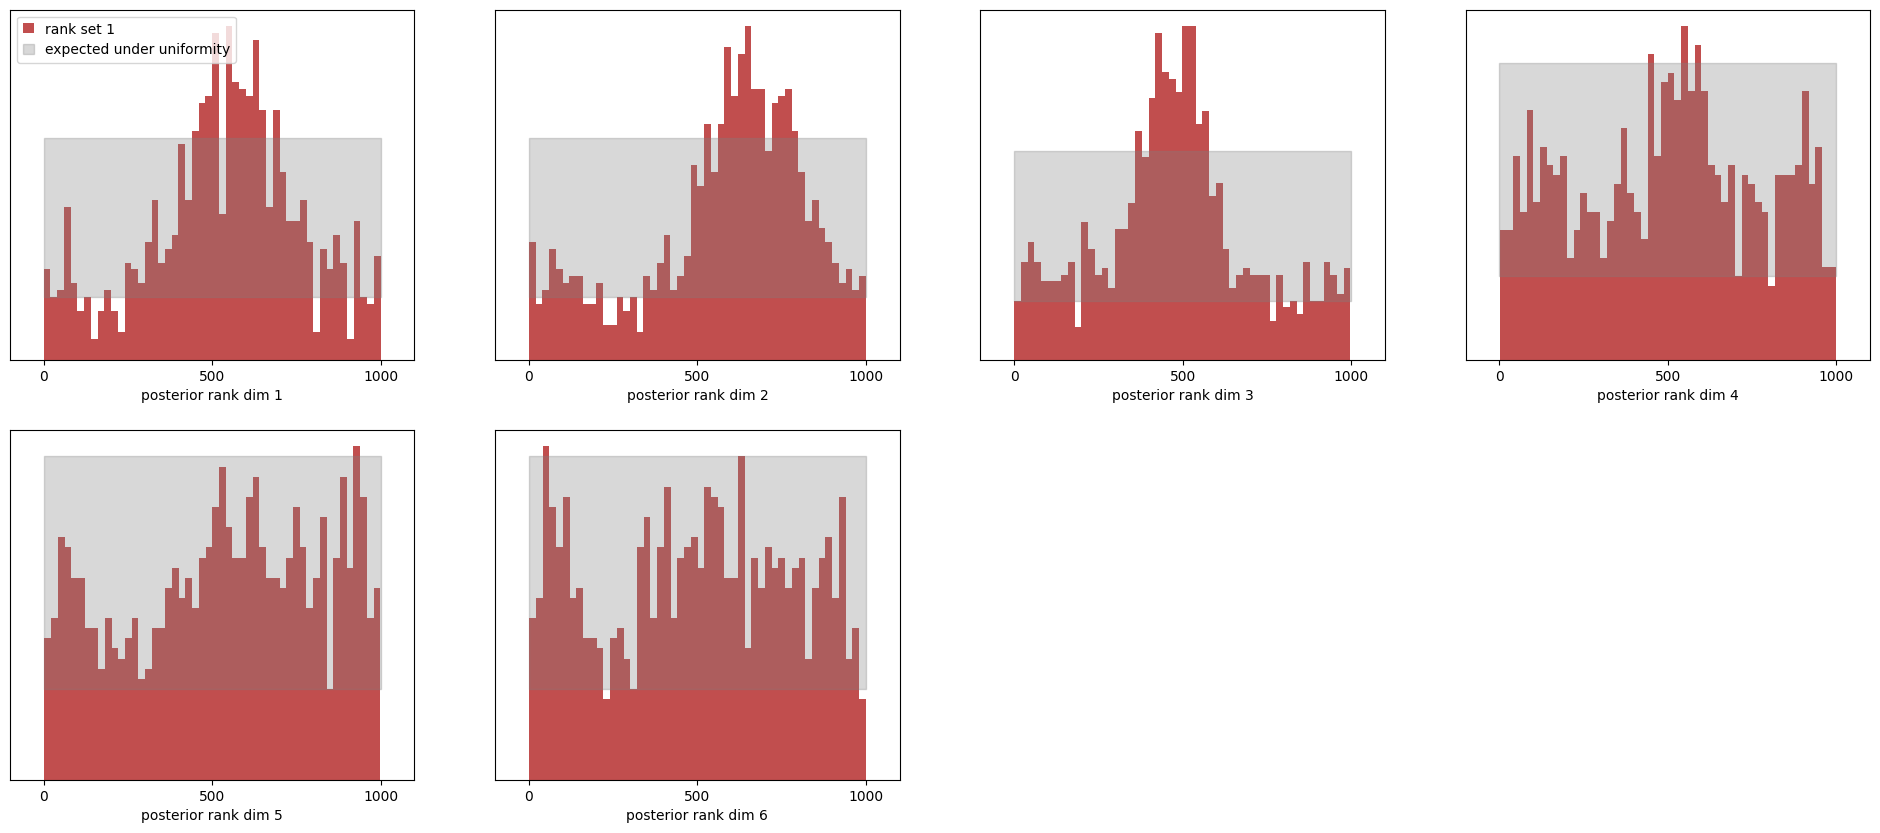

In [ ]:
idx = torch.randperm(len(theta_test))[:1000]

ranks, dap_samples = run_sbc(
    theta_test[idx], x_test[idx], posterior,
    num_posterior_samples=1000
)

from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=1000,
    plot_type="hist"
    )


check_sbc(ranks, theta_processed[idx], dap_samples)

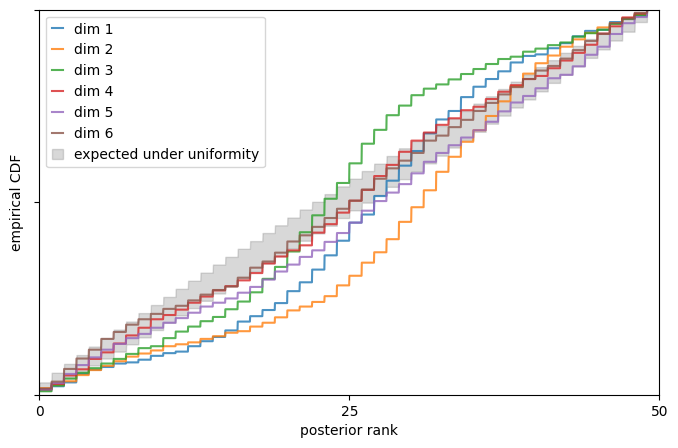

In [ ]:
from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=1000,
    plot_type="cdf"
    )

In [ ]:
from tqdm import tqdm

In [ ]:
preds = []

with torch.no_grad():
    for obs in tqdm(x_test):
        samples = posterior.sample((500,), x=obs, show_progress_bars=False, reject_outside_prior=False)
        samples[:, :3] = torch.exp(samples[:, :3].clamp(max=10))
        map_estimate = samples.median(dim=0).values
        preds.append(map_estimate.detach().cpu())
        del samples

preds = torch.stack(preds)

100%|██████████| 10000/10000 [05:28<00:00, 30.46it/s]


In [ ]:
preds[:, 3:] = preds[:, 3:].clamp(min=0)

In [ ]:
theta_test_ = theta_test.clone()
theta_test_[:, :3] = torch.exp(theta_test[:, :3])

mse = ((preds - theta_test_)**2).mean(dim=0)
rmse = mse.sqrt()

labels = ['a1', 'a2', 'a3', 'e1', 'e2', 'e3']
for i, label in enumerate(labels):
    print(f"{label}: RMSE = {rmse[i]:.4f}")

print(f"\nOverall RMSE: {rmse.mean():.4f}")

a1: RMSE = 50.7098
a2: RMSE = 1.3829
a3: RMSE = 1.3727
e1: RMSE = 0.0868
e2: RMSE = 0.0845
e3: RMSE = 0.0845

Overall RMSE: 8.9535


In [ ]:
theta_test_physical = theta_test.clone()
theta_test_physical[:, :3] = torch.exp(theta_test[:, :3])
print(theta_test_physical[:, 0].max())
print(theta_test_physical[:, 0].min())

tensor(9.9994)
tensor(0.5003)


In [ ]:
clean_mask = preds[:, 0] < 100

preds_clean = preds[clean_mask]
theta_clean = theta_test_[clean_mask]

mse = ((preds_clean - theta_clean)**2).mean(dim=0)
rmse = mse.sqrt()

labels = ['a1', 'a2', 'a3', 'e1', 'e2', 'e3']
for i, label in enumerate(labels):
    print(f"{label}: RMSE = {rmse[i]:.4f}")

print(f"\nOverall RMSE: {rmse.mean():.4f}")

a1: RMSE = 1.9300
a2: RMSE = 1.3804
a3: RMSE = 1.3721
e1: RMSE = 0.0868
e2: RMSE = 0.0844
e3: RMSE = 0.0844

Overall RMSE: 0.8230


## FMPE

In [ ]:
inference2 = FMPE(prior=prior2)
inference2.append_simulations(theta_train, x_train)
density_estimator2 = inference2.train()

/usr/local/lib/python3.12/dist-packages/sbi/inference/trainers/vfpe/base_vf_inference.py:167: UserWarning: Data has extreme outliers in dimension(s) [6, 7] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 405 epochs.

In [ ]:
posterior2 = inference2.build_posterior(density_estimator2)


/usr/local/lib/python3.12/dist-packages/sbi/utils/sbiutils.py:876: UserWarning: The passed discrete prior has no mean or stddev attribute, estimating them from samples to build affine standardizing transform.
  transform = prior_mean_std_transform(prior, device)


In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1e-6, 1e-6, 1e-3, 0.8, 0.9, 1.0, 0, 0, 0.1)))
x_obs[:3] = torch.log(x_obs[:3].clamp(min=1e-10))
a = x_obs[3:6]
x_obs[3:6] = torch.where(a > 0, torch.log(a.clamp(min=1e-3)), torch.full_like(a, -10.0))
x_obs[6:] = torch.clamp(x_obs[6:], min=0, max=10.0)

In [ ]:
posterior2.set_default_x(x_obs)

VectorFieldPosterior sampler for potential_fn=<VectorFieldBasedPotential>

In [ ]:
samples = posterior2.sample((1000,), x=x_obs, reject_outside_prior=False)
samples[:, :3] = torch.exp(samples[:, :3])
map_estimate = samples.mean(dim=0)

In [ ]:
map_estimate

tensor([2.4834, 2.6960, 1.5719, 0.1753, 0.1840, 0.1904])

In [ ]:
import pickle
with open('FMPE.pkl', 'wb') as f:
    pickle.dump(inference2, f)

/tmp/ipykernel_34589/73878024.py:3: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(inference2, f)


In [ ]:
torch.save(density_estimator2, 'density_estimator_FMPE.pt')

/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 200 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 500 samples for 500 observations:   0%|          | 0/500 [00:00<?, ?it/s]

Calculating ranks for 500 SBC samples:   0%|          | 0/500 [00:00<?, ?it/s]

{'ks_pvals': tensor([0., 0., 0., 0., 0., 0.]),
 'c2st_ranks': tensor([0.7160, 0.7350, 0.7240, 0.6860, 0.7090, 0.7020], dtype=torch.float64),
 'c2st_dap': tensor([0.5040, 0.4680, 0.5160, 0.5430, 0.5060, 0.5000], dtype=torch.float64)}

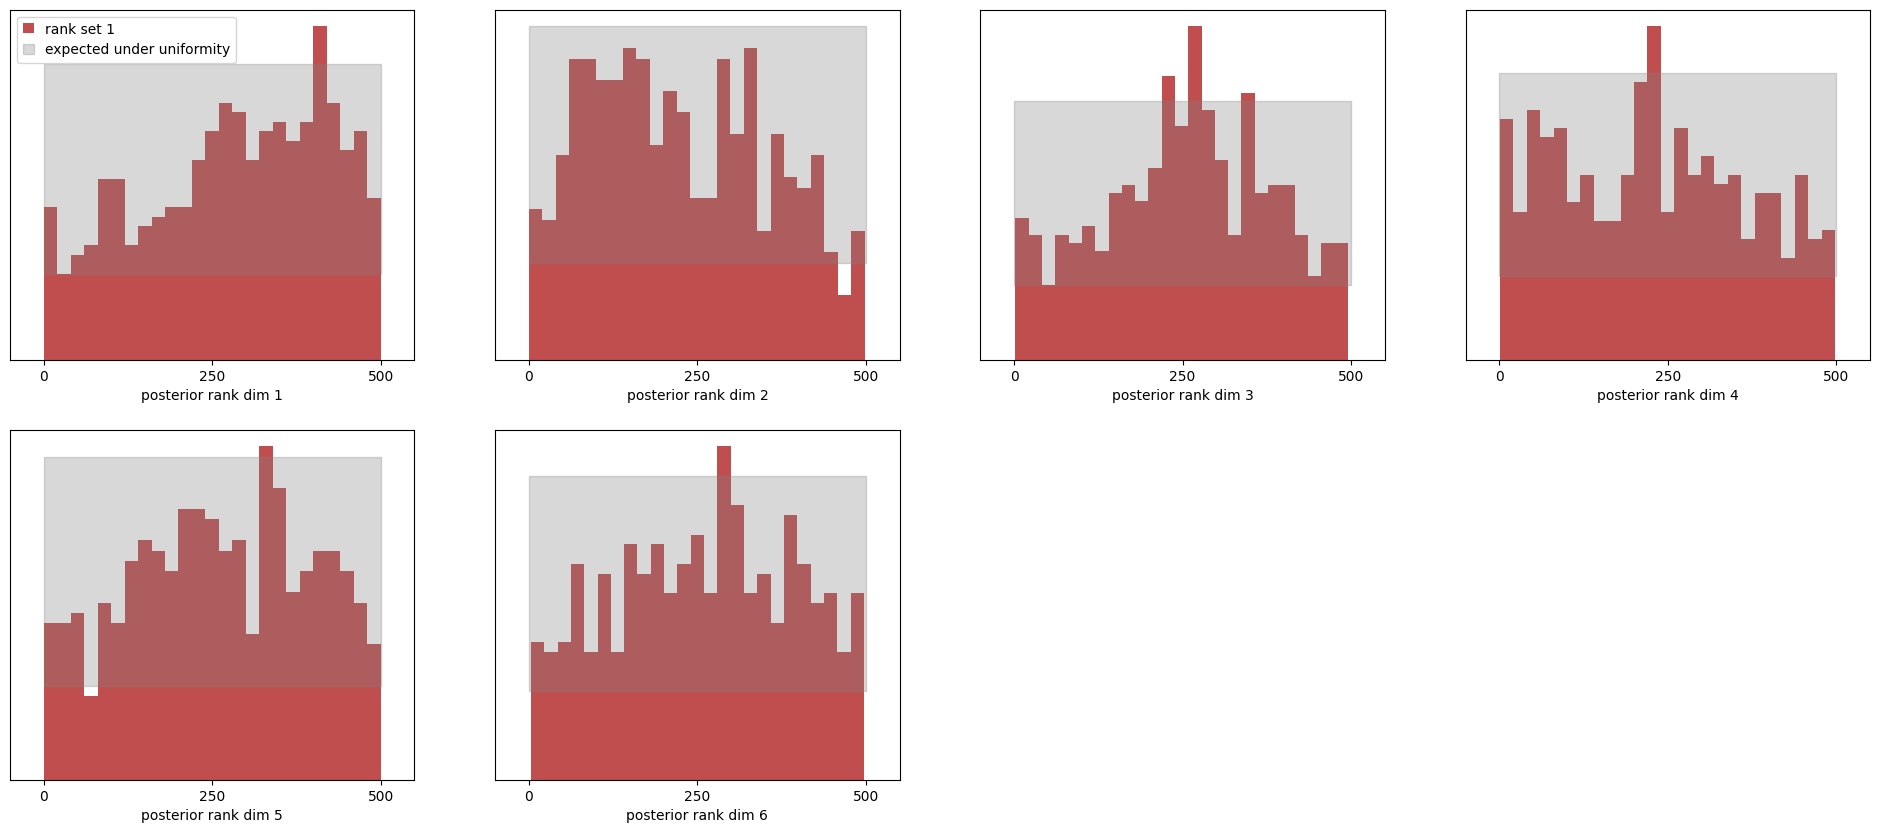

In [ ]:
idx = torch.randperm(len(theta_test))[:500]

ranks, dap_samples = run_sbc(
    theta_test[idx], x_test[idx], posterior2,
    num_posterior_samples=500
)

from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=500,
    plot_type="hist"
    )


check_sbc(ranks, theta_test[idx], dap_samples)

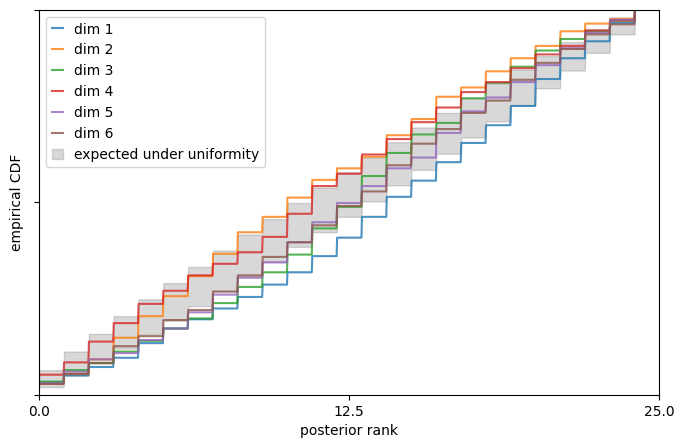

In [ ]:
from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=500,
    plot_type="cdf"
    )

In [ ]:
import os

In [ ]:
preds = []

with torch.no_grad():
    for obs in tqdm(x_test):
        samples = posterior2.sample((500,), x=obs, show_progress_bars=False, reject_outside_prior=False)
        samples[:, :3] = torch.exp(samples[:, :3].clamp(max=10))
        map_estimate = samples.median(dim=0).values
        preds.append(map_estimate.detach().cpu())
        del samples

preds = torch.stack(preds)

100%|██████████| 10000/10000 [2:22:43<00:00,  1.17it/s]


In [ ]:
np.save('preds_fmpe.npy', preds)

In [ ]:
theta_test_ = theta_test.clone()
theta_test_[:, :3] = torch.exp(theta_test[:, :3])

mse = ((preds - theta_test_)**2).mean(dim=0)
rmse = mse.sqrt()

labels = ['a1', 'a2', 'a3', 'e1', 'e2', 'e3']
for i, label in enumerate(labels):
    print(f"{label}: RMSE = {rmse[i]:.4f}")

print(f"\nOverall RMSE: {rmse.mean():.4f}")

a1: RMSE = 1.0791
a2: RMSE = 1.1994
a3: RMSE = 1.3266
e1: RMSE = 0.0807
e2: RMSE = 0.0781
e3: RMSE = 0.0814

Overall RMSE: 0.6409


## NPSE

In [ ]:
inference3 = NPSE(prior=prior2)
inference3.append_simulations(theta_train, x_train)
density_estimator3 = inference3.train()

 Neural network successfully converged after 222 epochs.

In [ ]:
import pickle
with open('NPSE.pkl', 'wb') as f:
    pickle.dump(inference3, f)

/tmp/ipykernel_34589/717895053.py:3: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tracker instance (instead of appending to the current one).
  pickle.dump(inference3, f)


In [ ]:
posterior3 = inference3.build_posterior(density_estimator3)


/usr/local/lib/python3.12/dist-packages/sbi/utils/sbiutils.py:876: UserWarning: The passed discrete prior has no mean or stddev attribute, estimating them from samples to build affine standardizing transform.
  transform = prior_mean_std_transform(prior, device)


In [ ]:
x_obs = torch.tensor(summary_statistics(simulate(1e-6, 1e-6, 1e-3, 0.8, 0.9, 1.0, 0, 0, 0.1)))
x_obs[:3] = torch.log(x_obs[:3].clamp(min=1e-10))
a = x_obs[3:6]
x_obs[3:6] = torch.where(a > 0, torch.log(a.clamp(min=1e-3)), torch.full_like(a, -10.0))
x_obs[6:] = torch.clamp(x_obs[6:], min=0, max=10.0)
posterior2.set_default_x(x_obs)
samples = posterior2.sample((1000,), x=x_obs, reject_outside_prior=False)
samples[:, :3] = torch.exp(samples[:, :3])
map_estimate = samples.mean(dim=0)


In [ ]:
map_estimate

tensor([2.4929, 2.6667, 1.5965, 0.1763, 0.1786, 0.1931])

In [ ]:
torch.save(density_estimator3, 'density_estimator_NPSE.pt')

Drawing 500 samples for 500 observations:   0%|          | 0/500 [00:00<?, ?it/s]

Generating 200 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

Generating 200 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

Generating 150 posterior samples in 499 diffusion steps.:   0%|          | 0/499 [00:00<?, ?it/s]

Calculating ranks for 500 SBC samples:   0%|          | 0/500 [00:00<?, ?it/s]

{'ks_pvals': tensor([0., 0., 0., 0., 0., 0.]),
 'c2st_ranks': tensor([0.7120, 0.7070, 0.7010, 0.6960, 0.6740, 0.7080], dtype=torch.float64),
 'c2st_dap': tensor([0.4710, 0.5090, 0.4760, 0.5440, 0.5120, 0.5280], dtype=torch.float64)}

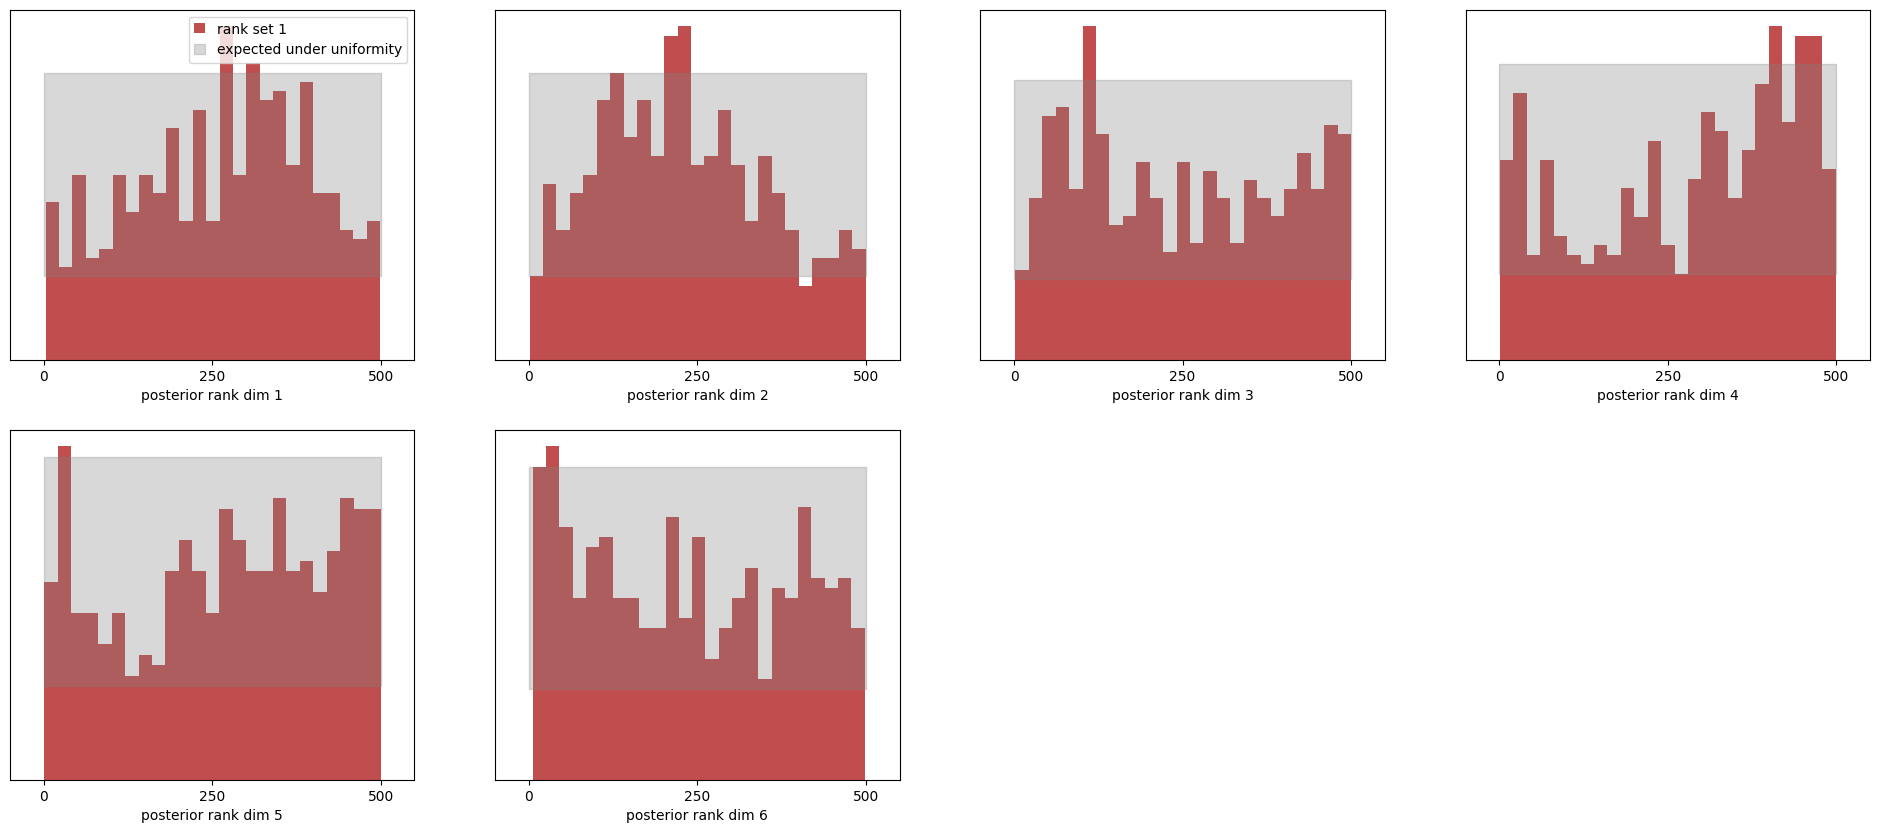

In [ ]:
idx = torch.randperm(len(theta_test))[:500]

ranks, dap_samples = run_sbc(
    theta_test[idx], x_test[idx], posterior3,
    num_posterior_samples=500
)

from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=500,
    plot_type="hist"
    )


check_sbc(ranks, theta_test[idx], dap_samples)

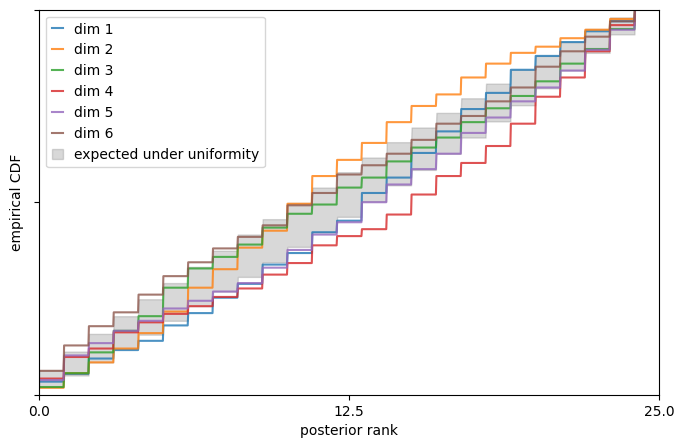

In [ ]:
from sbi.analysis import sbc_rank_plot
f, ax = sbc_rank_plot(
    ranks=ranks,
    num_posterior_samples=500,
    plot_type="cdf"
    )

In [ ]:
idx = torch.randperm(len(x_test))[:1000]

preds = []

with torch.no_grad():
    for obs in tqdm(x_test[idx]):
        samples = posterior3.sample((500,), x=obs, show_progress_bars=False, reject_outside_prior=False)
        samples[:, :3] = torch.exp(samples[:, :3].clamp(max=10))
        samples[:, 3:] = samples[:, 3:].clamp(min=0)
        map_estimate = samples.median(dim=0).values
        preds.append(map_estimate.detach().cpu())
        del samples

preds = torch.stack(preds)


100%|██████████| 1000/1000 [42:18<00:00,  2.54s/it]


In [ ]:
np.save('preds_npse.npy', preds)

In [ ]:
theta_test_ = theta_test[idx].clone()
theta_test_[:, :3] = torch.exp(theta_test[idx][:, :3])

mse = ((preds - theta_test_)**2).mean(dim=0)
rmse = mse.sqrt()

labels = ['a1', 'a2', 'a3', 'e1', 'e2', 'e3']
for i, label in enumerate(labels):
    print(f"{label}: RMSE = {rmse[i]:.4f}")

print(f"\nOverall RMSE: {rmse.mean():.4f}")

a1: RMSE = 1.2349
a2: RMSE = 1.1715
a3: RMSE = 1.4365
e1: RMSE = 0.0810
e2: RMSE = 0.0772
e3: RMSE = 0.0774

Overall RMSE: 0.6798
